In [1]:
from datascience import *
import numpy as np

%matplotlib inline
import matplotlib.pyplot as plots
plots.style.use('fivethirtyeight')

# Comparing Two Samples

In [2]:
births = Table.read_table('baby.csv')

In [3]:
births

Birth Weight,Gestational Days,Maternal Age,Maternal Height,Maternal Pregnancy Weight,Maternal Smoker
120,284,27,62,100,False
113,282,33,64,135,False
128,279,28,64,115,True
108,282,23,67,125,True
136,286,25,62,93,False
138,244,33,62,178,False
132,245,23,65,140,False
120,289,25,62,125,False
143,299,30,66,136,True
140,351,27,68,120,False


In [4]:
smoking_and_birthweight = births.select('Maternal Smoker', 'Birth Weight')

In [5]:
smoking_and_birthweight.group('Maternal Smoker')

Maternal Smoker,count
False,715
True,459


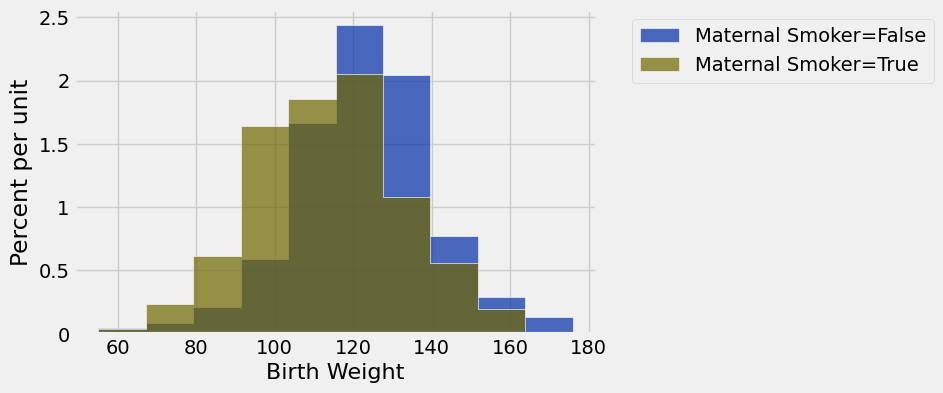

In [6]:
smoking_and_birthweight.hist('Birth Weight', group='Maternal Smoker')

# Test Statistic

[Question] What values of our statistic are in favor of the alternative: positive or negative?

In [8]:
means_table = smoking_and_birthweight.group('Maternal Smoker', np.average)
means_table

Maternal Smoker,Birth Weight average
False,123.085
True,113.819


In [9]:
means = means_table.column(1)
observed_difference = means.item(1) - means.item(0)
observed_difference

-9.266142572024918

In [10]:
def difference_of_means(table, label, group_label):
    """Takes: name of table, column label of numerical variable,
    column label of group-label variable
    Returns: Difference of means of the two groups"""
    
    #table with the two relevant columns
    reduced = table.select(label, group_label)  
    
    # table containing group means
    means_table = reduced.group(group_label, np.average)
    # array of group means
    means = means_table.column(1)
    
    return means.item(1) - means.item(0)

In [11]:
difference_of_means(births, 'Birth Weight', 'Maternal Smoker')

-9.266142572024918

# Random Permutation (Shuffling)

In [12]:
letters = Table().with_column('Letter', make_array('a', 'b', 'c', 'd', 'e'))

In [13]:
letters.sample()

Letter
d
c
a
b
e


In [14]:
letters.sample(with_replacement = False)

Letter
b
e
a
c
d


In [15]:
letters.with_column('Shuffled', letters.sample(with_replacement = False).column(0))

Letter,Shuffled
a,e
b,b
c,c
d,a
e,d


# Simulation Under Null Hypothesis

In [16]:
smoking_and_birthweight

Maternal Smoker,Birth Weight
False,120
False,113
True,128
True,108
False,136
False,138
False,132
False,120
True,143
False,140


In [17]:
shuffled_labels = smoking_and_birthweight.sample(with_replacement=False).column('Maternal Smoker')

In [18]:
original_and_shuffled = smoking_and_birthweight.with_column(
    'Shuffled Label', shuffled_labels
)

In [19]:
original_and_shuffled

Maternal Smoker,Birth Weight,Shuffled Label
False,120,False
False,113,True
True,128,False
True,108,True
False,136,False
False,138,False
False,132,True
False,120,True
True,143,False
False,140,False


In [20]:
difference_of_means(original_and_shuffled, 'Birth Weight', 'Shuffled Label')

-1.9435105199811034

In [21]:
difference_of_means(original_and_shuffled, 'Birth Weight', 'Maternal Smoker')

-9.266142572024918

# Permutation Test

In [22]:
def one_simulated_difference(table, label, group_label):
    """Takes: name of table, column label of numerical variable,
    column label of group-label variable
    Returns: Difference of means of the two groups after shuffling labels"""
    
    # array of shuffled labels
    shuffled_labels = table.sample(with_replacement = False).column(group_label)
    
    # table of numerical variable and shuffled labels
    shuffled_table = table.select(label).with_column('Shuffled Label', shuffled_labels)
    
    return difference_of_means(shuffled_table, label, 'Shuffled Label')   

In [23]:
one_simulated_difference(births, 'Birth Weight', 'Maternal Smoker')

1.9700016758840206

In [24]:
differences = make_array()

for i in np.arange(2500):
    new_difference = one_simulated_difference(births, 'Birth Weight', 'Maternal Smoker')
    differences = np.append(differences, new_difference)

Observed Difference: -9.266142572024918


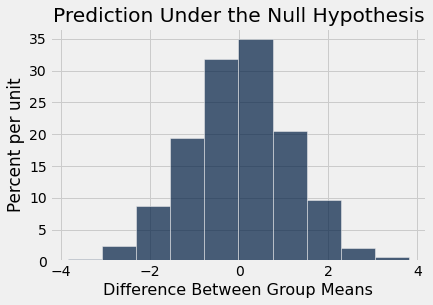

In [25]:
Table().with_column('Difference Between Group Means', differences).hist()
print('Observed Difference:', observed_difference)

plots.title('Prediction Under the Null Hypothesis');

**t - test for the difference of the mean for independent samples**

A two-sample t-test could be used because we are comparing the mean birth weights of two independent groups (smokers and non-smokers).

The main assumptions are:

1. Observations are independent.
2. The two groups are independent.
3. The sampling distribution of the mean is approximately normal (or the sample size is large).
4. Equal variances are required only for the pooled t-test, not Welch's t-test.

Since the sample size is large (1174 mother-baby pairs), the Central Limit Theorem makes the normality assumption less important.


# Independent Two-Sample t-Test for Difference of Means

In this example, we compare the average birth weight of babies born to smoking mothers and non-smoking mothers using an independent two-sample t-test.

## Step 1: State the Hypotheses

Let

- $\mu_1$ = mean birth weight for babies born to smoking mothers
- $\mu_2$ = mean birth weight for babies born to non-smoking mothers

We want to test whether babies born to smoking mothers have a lower average birth weight.

$$
H_0:\mu_1=\mu_2
$$

$$
H_a:\mu_1<\mu_2
$$

This is a **left-tailed test**.

---

## Step 2: Verify Conditions

The sample sizes are large:

$$
n_1 = 459
$$

$$
n_2 = 715
$$

Since both sample sizes are much larger than 30, the sampling distribution of the difference in sample means is approximately normal by the Central Limit Theorem.

---

## Step 3: Sample Statistics

### Smoking Mothers

Sample size:

$$
n_1 = 459
$$

Sample mean:

$$
\bar x_1 = 113.82
$$

Sample standard deviation:

$$
s_1 = 18.30
$$

### Non-Smoking Mothers

Sample size:

$$
n_2 = 715
$$

Sample mean:

$$
\bar x_2 = 123.09
$$

Sample standard deviation:

$$
s_2 = 17.42
$$

Observed difference:

$$
\bar x_1-\bar x_2
=
113.82-123.09
=
-9.27
$$

Babies born to smoking mothers weigh about 9.27 ounces less on average.

---

## Step 4: Compute the Test Statistic

The standard error of the difference in sample means is

$$
SE
=
\sqrt{
\frac{s_1^2}{n_1}
+
\frac{s_2^2}{n_2}
}
$$

Substituting the values:

$$
SE
=
\sqrt{
\frac{18.30^2}{459}
+
\frac{17.42^2}{715}
}
$$

The t statistic is

$$
t
=
\frac{
(\bar x_1-\bar x_2)-0
}
{
SE
}
$$

$$
t
=
-8.626
$$

---

## Step 5: Degrees of Freedom

For this analysis, we use

$$
df=\min(n_1-1,n_2-1)
$$

$$
df=\min(458,714)
$$

$$
df=458
$$

Because the degrees of freedom are very large, the t-distribution is very close to the standard normal distribution.

---

## Step 6: Compute the P-value

Since this is a left-tailed test:

$$
P\text{-value}
=
P(T_{458}<-8.626)
$$

Using the t-distribution:

$$
P\text{-value}
=
5.23\times10^{-17}
$$

or

$$
0.0000000000000000523
$$

This value is essentially zero.

---

## Step 7: Make a Decision

Using

$$
\alpha = 0.01
$$

Compare the P-value to the significance level:

$$
5.23\times10^{-17}
<
0.01
$$

Since the P-value is much smaller than $\alpha$,

**Reject $H_0$.**

---

## Step 8: Conclusion

There is overwhelming statistical evidence to support the claim that babies born to smoking mothers have a lower average birth weight than babies born to non-smoking mothers.

The sample data indicate that smoking during pregnancy is associated with a substantial reduction in average birth weight.

---

## Connection to Data 8 A/B Testing

In Data 8, we could analyze the same question using a permutation test:

1. Assume smoking status has no effect on birth weight.
2. Randomly shuffle the smoking labels.
3. Compute the difference in means for each shuffle.
4. Estimate the P-value as the proportion of shuffled differences at least as extreme as the observed difference.

### Traditional Statistics

Uses a theoretical t-distribution:

$$
t
=
\frac{
(\bar x_1-\bar x_2)-0
}
{
\sqrt{\frac{s_1^2}{n_1}+\frac{s_2^2}{n_2}}
}
$$

### Data 8 Approach

Uses simulation to approximate the null distribution empirically.

When sample sizes are large, both methods typically lead to the same conclusion.

# Comparison: A/B Test vs Two-Sample t-Test

Both A/B tests and two-sample t-tests compare two groups, but they answer the question in different ways.

| Feature | A/B Test (Permutation Test) | Two-Sample t-Test |
|----------|----------|----------|
| Purpose | Determine whether an observed difference could be due to chance | Determine whether two population means differ |
| Null Hypothesis | Group labels are unrelated to the response variable | Population means are equal |
| Test Statistic | Often the difference in sample means | Difference in sample means standardized by its estimated standard error |
| Method | Randomly shuffle labels many times to simulate the null distribution | Use the theoretical t distribution |
| Assumptions | Independent observations | Independent observations and approximately normal sampling distribution of the mean |
| Equal Variance Assumption | Not required | Required only for the pooled t-test; not for Welch's t-test |
| Uses Simulation? | Yes | No |
| P-value Computation | Based on simulated null distribution | Based on the t distribution |
| Best For | Learning inference, fewer assumptions, flexible situations | Traditional statistical inference and confidence intervals |

## A/B Test (Permutation Test)

Null hypothesis:

$$
H_0: \text{Group labels do not matter.}
$$

Under the null hypothesis, the response values stay fixed and the group labels can be shuffled.

Steps:

1. Compute the observed difference in means.
2. Randomly shuffle the group labels.
3. Recompute the difference in means.
4. Repeat many times.
5. Compare the observed statistic to the simulated distribution.

## Two-Sample t-Test

Null hypothesis:

$$
H_0:\mu_1=\mu_2.
$$

The test statistic is

$$
t=
\frac{\bar{x}_1-\bar{x}_2}
{\sqrt{\frac{s_1^2}{n_1}+\frac{s_2^2}{n_2}}}.
$$

The p-value is obtained from the t distribution.

## Relationship

When sample sizes are large, the results from a permutation test and a two-sample t-test are often very similar.

For the birth-weight example:

- Group 1: Babies of smoking mothers
- Group 2: Babies of non-smoking mothers

Both methods test whether the average birth weights differ between the two groups.

Data 8 typically uses a permutation test because it relies on fewer assumptions and emphasizes simulation-based inference.

## Data 8 vs Traditional Statistics

One way to think about Data 8 is that it teaches statistical inference through simulation, while traditional statistics often teaches inference through probability theory and theoretical distributions.

### Data 8 Approach

Data 8 typically uses simulation to approximate the sampling distribution or null distribution.

For example:

- A/B tests use permutation tests.
- Confidence intervals are often built using bootstrap samples.
- Hypothesis tests use simulated null distributions.

Rather than deriving a theoretical distribution, Data 8 generates thousands of simulated samples and observes the empirical distribution of the statistic.

### Traditional Statistics Approach

Traditional statistics often relies on probability theory and known sampling distributions.

Examples include:

- Using the Central Limit Theorem to justify a normal approximation for sample means.
- Using the normal approximation to the Binomial distribution for proportions.
- Using the t distribution for inference about means when the population standard deviation is unknown.

Instead of simulating the distribution, traditional methods derive it mathematically and use theoretical probability calculations.

### Relationship Between the Two

Both approaches are trying to answer the same question:

> How unusual is the observed statistic under the null hypothesis?

Data 8 answers this question by simulating the distribution empirically.

Traditional statistics answers this question using a theoretical distribution derived from probability theory.

For large samples, the two approaches often produce very similar results.

### Example: Comparing Two Groups

Suppose we want to compare the mean birth weights of babies born to smoking and non-smoking mothers.

**Data 8:**
- Compute the observed difference in means.
- Randomly shuffle the smoking labels many times.
- Build a permutation distribution.
- Estimate the p-value from the simulation.

**Traditional Statistics:**
- Compute the observed difference in means.
- Calculate a t-statistic.
- Use the t distribution to obtain a p-value.

Both methods measure evidence against the null hypothesis, but one uses simulation while the other uses a theoretical distribution.

### Why Learn Both?

Learning both approaches provides a deeper understanding of statistical inference.

- Simulation helps build intuition about randomness and sampling variability.
- Probability theory explains why the simulation works and provides efficient analytical methods.
- Seeing both perspectives helps students connect practical computation with statistical theory.

In many modern applications, simulation and theory complement each other rather than compete with each other.